<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_32_CNN_vs_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import layers

print(tf.__version__)

2.20.0


In [4]:
!git clone https://github.com/Rafid013/CRISPRpredSEQ.git

Cloning into 'CRISPRpredSEQ'...
remote: Enumerating objects: 338, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 338 (delta 22), reused 25 (delta 9), pack-reused 292 (from 1)
Receiving objects: 100% (338/338), 225.43 MiB | 29.08 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (84/84), done.


In [8]:
import os

for root, dirs,files in os.walk("CRISPRpredSEQ"):
  for file in files:
    if file.endswith(".csv") or file.endswith(".xlsx"):
      print(os.path.join(root, file))

CRISPRpredSEQ/example1.csv
CRISPRpredSEQ/example2.csv
CRISPRpredSEQ/deephf_data.xlsx
CRISPRpredSEQ/Data/hela.csv
CRISPRpredSEQ/Data/hct116.csv
CRISPRpredSEQ/Data/hl60.csv
CRISPRpredSEQ/Data/hek293.csv
CRISPRpredSEQ/TMP/test_leave_hl60.csv
CRISPRpredSEQ/TMP/test_leave_hela.csv
CRISPRpredSEQ/TMP/test_leave_hct116.csv
CRISPRpredSEQ/TMP/train_leave_hct116.csv
CRISPRpredSEQ/TMP/train_leave_hl60.csv
CRISPRpredSEQ/TMP/train_leave_hela.csv
CRISPRpredSEQ/Results/test_results.csv
CRISPRpredSEQ/Results/loc_results.csv
CRISPRpredSEQ/Results/final_loc_results.csv
CRISPRpredSEQ/Results/final_test_results.csv


In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras import layers

data_path = "CRISPRpredSEQ/Data/hek293.csv"
df = pd.read_csv(data_path)
df.head()

,sgRNA,label
0,GGCTGCTTTACCCGCTGTGGGGG,1
1,TCCGGGTTGGCCTTCCACTGGGG,1
2,CAGCATCCTTCGGAAAGCTCTGG,1
3,CGGTAGAAGCAGGTAGTCTGGGG,1
4,CATCCCGCTGCCCCAGTGGAAGG,1


In [12]:
print(df.shape)
print(df.columns)
df.info()


(2333, 2)
Index(['sgRNA', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2333 entries, 0 to 2332
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sgRNA   2333 non-null   object
 1   label   2333 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 36.6+ KB


In [13]:
df.head(10)

,sgRNA,label
0,GGCTGCTTTACCCGCTGTGGGGG,1
1,TCCGGGTTGGCCTTCCACTGGGG,1
2,CAGCATCCTTCGGAAAGCTCTGG,1
3,CGGTAGAAGCAGGTAGTCTGGGG,1
4,CATCCCGCTGCCCCAGTGGAAGG,1
5,GATCAGGGCGCGGTAGAAGCAGG,1
6,TCTTGTCCAGAGCTTTCCGAAGG,1
7,AACCGCCAAGGCCGATGCAGAGG,0
8,AGGCTGCTTTACCCGCTGTGGGG,1
9,AGGACCGAGTAGTCATCCTGGGG,1


In [14]:
df.columns

Index(['sgRNA', 'label'], dtype='object')

In [15]:
df['label'].value_counts()

,count
label,
1,1374
0,959


Text(0, 0.5, 'Number of Samples')

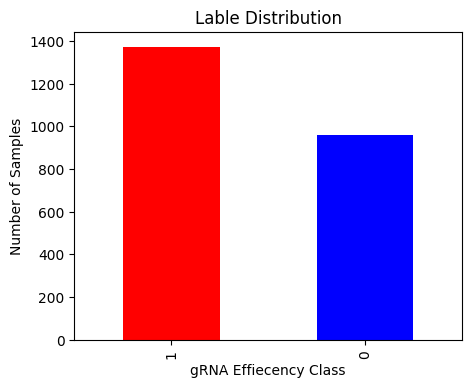

In [17]:
plt.figure(figsize=(5,4))
df['label'].value_counts().plot(
    kind='bar',
    color=['red','blue']
)
plt.title("Lable Distribution")
plt.xlabel("gRNA Effiecency Class")
plt.ylabel("Number of Samples")

In [18]:
df = df.dropna()
print(df.shape)

(2333, 2)


In [20]:
sequences = df['sgRNA'].astype(str)
labels = df['label']


In [21]:
sequences.str.len().value_counts()

,count
sgRNA,
23,2333


In [22]:
labels.unique()

array([1, 0])

In [23]:
y=labels.values

In [25]:
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

In [26]:
mapping ={
    'A':[1,0,0,0],
    'T':[0,1,0,0],
    'C':[0,0,1,0],
    'G':[0,0,0,1]
}


In [27]:
def one_hot_encode(sequence):
    encoded = []
    for nucleotide in sequence:
            encoded.append(mapping[nucleotide])
    return np.array(encoded)

In [28]:
X = np.array(
    sequences.apply(one_hot_encode).tolist()
)
print(X.shape)

(2333, 23, 4)


In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [30]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1866, 23, 4)
(1866,)
(467, 23, 4)
(467,)


In [31]:
cnn = Sequential([
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(23,4)
    ),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(
        units=64,
        activation='relu'
    ),
    Dense(
        units=1,
        activation='sigmoid'
    )
])

cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 21, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,921 (163.75 KB)

 Trainable params: 41,921 (163.75 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_cnn = cnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9544 - loss: 0.2319 - val_accuracy: 0.6631 - val_loss: 0.6705
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9645 - loss: 0.2106 - val_accuracy: 0.6551 - val_loss: 0.6862
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9692 - loss: 0.1986 - val_accuracy: 0.6604 - val_loss: 0.6837
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9732 - loss: 0.1828 - val_accuracy: 0.6684 - val_loss: 0.7124
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9772 - loss: 0.1696 - val_accuracy: 0.6417 - val_loss: 0.7093
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9832 - loss: 0.1589 - val_accuracy: 0.6444 - val_loss: 0.7398
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9846 - loss: 0.1483 - val_accuracy: 0.6524 - val_loss: 0.7286
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9873 - loss: 0.1364 - val_accuracy: 0.6578 - val_loss:

In [39]:
lstm = Sequential([
    LSTM(
        units=64,
        input_shape=(23,4)
    ),
    Dense(
        units=64,
        activation='relu'
    )
  ,

    Dropout(0.3),

    Dense(
        units=1,
        activation='sigmoid'
    )])

lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,889 (85.50 KB)

 Trainable params: 21,889 (85.50 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_lstm = lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5777 - loss: 0.6809 - val_accuracy: 0.5775 - val_loss: 0.6799
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5918 - loss: 0.6785 - val_accuracy: 0.5775 - val_loss: 0.6787
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5918 - loss: 0.6753 - val_accuracy: 0.5775 - val_loss: 0.6769
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5918 - loss: 0.6748 - val_accuracy: 0.5775 - val_loss: 0.6727
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5918 - loss: 0.6733 - val_accuracy: 0.5775 - val_loss: 0.6710
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5912 - loss: 0.6750 - val_accuracy: 0.5775 - val_loss: 0.6762
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5918 - loss: 0.6726 - val_accuracy: 0.5775 - val_loss: 0.6724
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5918 - loss: 0.6716 - val_accuracy: 0.5775 - v

In [41]:
cnn_loss, cnn_acc = cnn.evaluate(X_test, y_test)
print("CNN Accuracy:",cnn_acc)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5931 - loss: 1.2694 
CNN Accuracy: 0.5931477546691895


In [42]:
lstm_loss, lstm_acc = lstm.evaluate(X_test, y_test)
print("LSTM Accuracy:",lstm_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5931 - loss: 0.6689
LSTM Accuracy: 0.5931477546691895


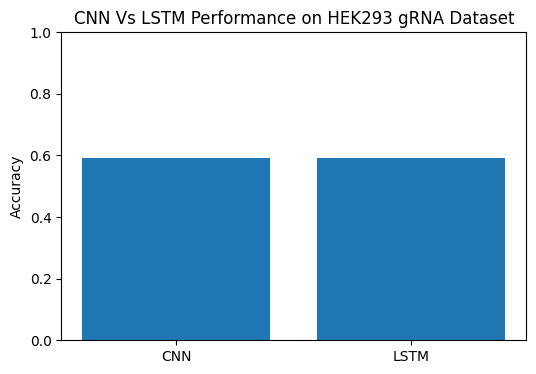

In [43]:
models =['CNN','LSTM']
accuracy = [
    cnn_acc,
    lstm_acc
]

plt.figure(figsize=(6,4))
plt.bar(models,accuracy)
plt.title("CNN Vs LSTM Performance on HEK293 gRNA Dataset")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


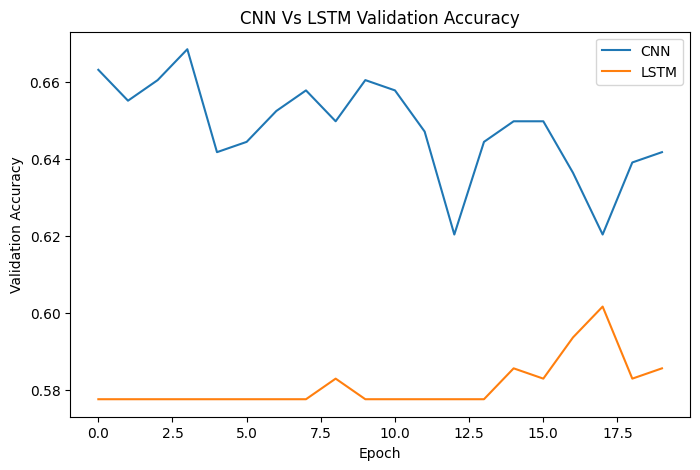

In [45]:
plt.figure(figsize=(8,5))
plt.plot(
    history_cnn.history['val_accuracy'],
    label='CNN'
)
plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)
plt.xlabel ("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("CNN Vs LSTM Validation Accuracy")
plt.legend()
plt.show()